# Step 7 - Prototype inversion

Invert the observed testset (step 5) with all the machinery: start from the pretrained FAL-C field
(warm start) and optimise its weights against **fit** chi^2 + **HE** + **boundary**, with fresh random
fit pixels and collocation points every step. Training is **continuable** (re-run the continue cell to
add steps) and uses an **exponential-decay LR schedule** (standard for PINNs). Per-Stokes fit weights
are hand-set in `invert.run_inversion` (`sigma_stokes`).

In [26]:
import os, sys
sys.path.insert(0, os.path.abspath('.')); sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../3dtesting')); sys.path.insert(0, os.path.abspath('../eos_mlp'))
import gpu; dev = gpu.use_gpu()
%matplotlib inline
import time, numpy as np, matplotlib.pyplot as plt, jax
import atmosphere_field as af, rt_forward as rf, invert, pretrain as pt, eos as eos_mod
from synth3d import read_kurucz, DEFAULT_LINELIST
print('CUDA_VISIBLE_DEVICES =', dev, '| jax backend:', jax.default_backend())

CUDA_VISIBLE_DEVICES = 2 | jax backend: gpu


In [28]:
params0 = af.load_params('/dat/milic/adora_pinn_develop/pretrained_field.npz')  # warm start
eos_params = eos_mod.load_eos('pg')
d = np.load('/dat/milic/adora_pinn_develop/inversion_testset.npz', allow_pickle=True)
obs = np.asarray(d['I_obs']); 
waves = np.asarray(d['waves'])
adata = read_kurucz(DEFAULT_LINELIST)


In [29]:
nx, ny, nz = 128, 128, 56; 
dz = np.full(nz, 20.0e3); 
P_TOP = 3.75
coords = af.grid_coords(nx, ny, nz); mc = float(obs[..., 0, 0].mean())

def misfit(I):
    return {s: float(np.sqrt(np.mean((I[:,:,k]-obs[:,:,k])**2))/mc) for k, s in enumerate('IQUV')}

def show_hist(ck):
    h = ck['hist']; fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), layout='constrained')
    for kk in ['fit','he','bnd','total']: ax[0].semilogy(h['step'], h[kk], label=kk)
    ax[0].set(xlabel='step', ylabel='loss (monitor set)', title=f"losses ({ck['step']} steps)"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
    ax[1].semilogy(h['step'], h['lr']); ax[1].set(xlabel='step', ylabel='learning rate', title='LR schedule (exp decay)'); ax[1].grid(alpha=.3)
    plt.show()
print('obs', obs.shape)

obs (128, 128, 4, 201)


### Initial (warm-start) misfit

In [30]:
I0 = np.asarray(rf.synth_field(params0, coords, (nx,ny,nz), waves, dz, batch=4096, progress=False))
m0 = misfit(I0); print('initial RMS(model-obs)/<Ic>:', {k: f'{v:.3e}' for k,v in m0.items()})

initial RMS(model-obs)/<Ic>: {'I': '1.978e-01', 'Q': '1.225e-03', 'U': '1.159e-03', 'V': '9.288e-03'}


### Run the inversion (fresh)
Returns a checkpoint `ckpt = {params, state, key, step, hist, monitor}`.

invert:   0%|          | 0/20000 [00:00<?, ?step/s]

20000 steps in 4408s


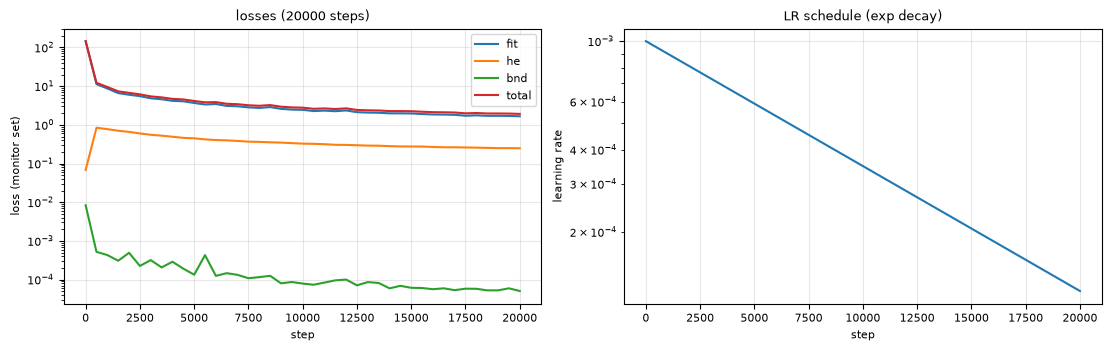

In [31]:
t0 = time.time()
ckpt = invert.run_inversion(params0, eos_params, obs, waves, dz, adata, P_TOP,
                            steps=20000, m_fit=1024, k_he=4096, m_bnd=1024,
                            w_fit=1.0, w_he=1.0, w_bnd=1.0e2,
                            lr=1.0e-3, lr_decay=0.9, lr_transition=1000, nz=nz)
print(f'{ckpt["step"]} steps in {time.time()-t0:.0f}s')
show_hist(ckpt)

invert:   0%|          | 0/1000 [00:00<?, ?step/s]

total steps: 2000


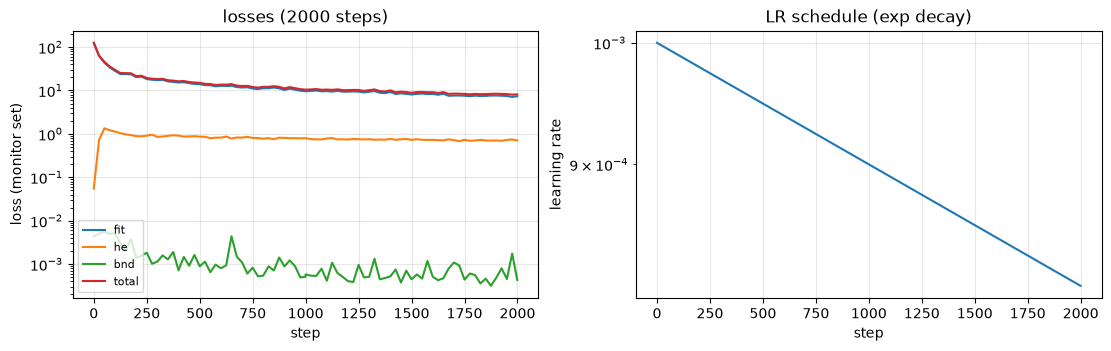

In [ ]:
### Continue training

ckpt = invert.run_inversion(ckpt, eos_params, obs, waves, dz, adata, P_TOP,
                            steps=1000, m_fit=384, k_he=1024, m_bnd=256,
                            w_fit=1.0, w_he=1.0, w_bnd=1.0e2,
                            lr=1.0e-3, lr_decay=0.9, lr_transition=1000, nz=nz)
print(f'total steps: {ckpt["step"]}')
show_hist(ckpt)

### Recovered spectra vs observations

misfit RMS(model-obs)/<Ic>   initial -> final:
  I: 1.978e-01 -> 2.207e-02
  Q: 1.225e-03 -> 1.122e-03
  U: 1.159e-03 -> 1.064e-03
  V: 9.288e-03 -> 5.071e-03


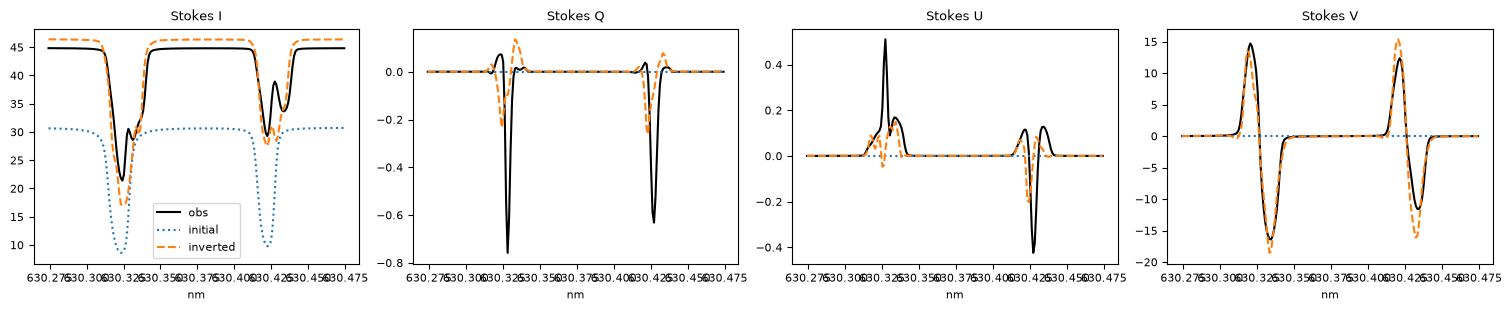

In [32]:
params = ckpt['params']
I1 = np.asarray(rf.synth_field(params, coords, (nx,ny,nz), waves, dz, batch=4096, progress=False))
m1 = misfit(I1)
print('misfit RMS(model-obs)/<Ic>   initial -> final:')
for s in 'IQUV': print(f'  {s}: {m0[s]:.3e} -> {m1[s]:.3e}')
iV = np.unravel_index(np.argmax(np.abs(obs[:,:,3,:]).max(-1)), (nx,ny))
fig, ax = plt.subplots(1, 4, figsize=(15, 3), layout='constrained')
for a, k, s in zip(ax, range(4), 'IQUV'):
    a.plot(waves, obs[iV[0],iV[1],k], 'k-', label='obs')
    a.plot(waves, I0[iV[0],iV[1],k], 'C0:', label='initial')
    a.plot(waves, I1[iV[0],iV[1],k], 'C1--', label='inverted')
    a.set(title=f'Stokes {s}', xlabel='nm')
ax[0].legend(fontsize=8); plt.show()

### Recovered maps
Continuum and Stokes V (obs vs inverted), and the recovered Bz and vz at the photosphere.

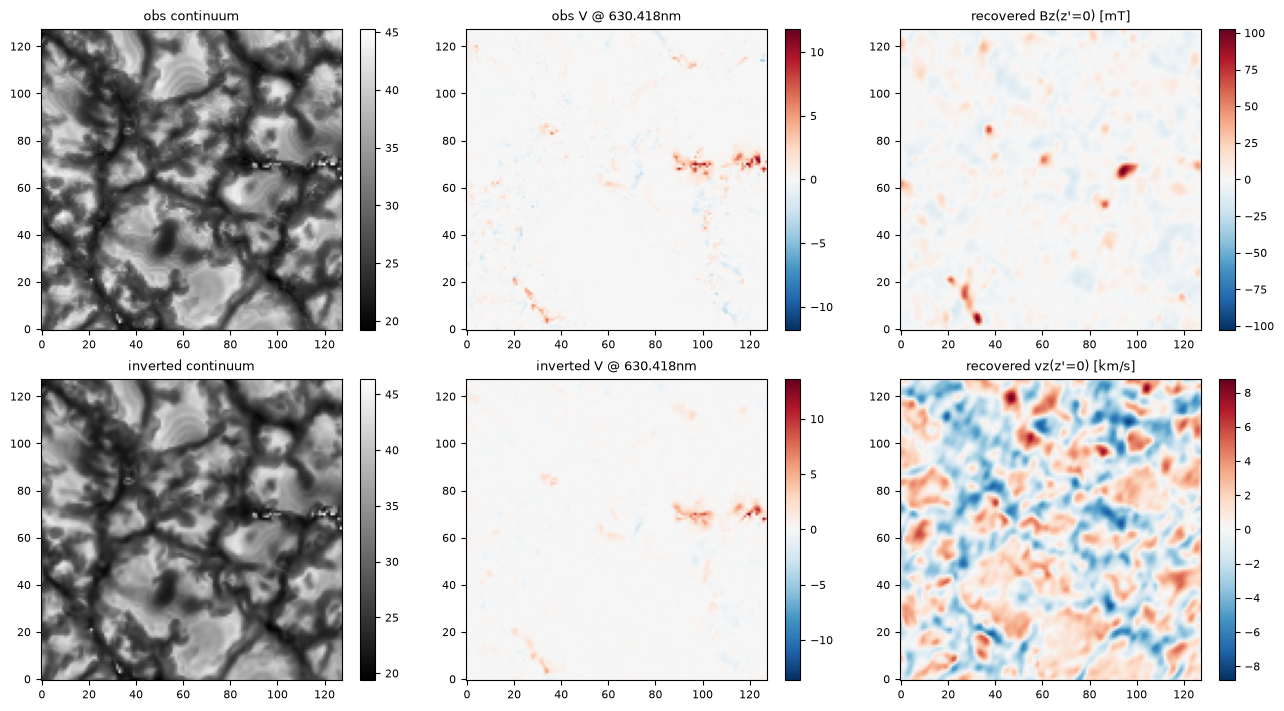

In [33]:
kw = int(np.argmax(np.abs(obs[:,:,3,:]).mean((0,1))))
pred = pt.predict_grid(params, coords); iz0 = 5   # z'~0 (-100 + 5*20 = 0 km)
Bz = pred['Bz'].reshape(nx,ny,nz)[:,:,iz0]; vz = pred['vz'].reshape(nx,ny,nz)[:,:,iz0]
fig, ax = plt.subplots(2, 3, figsize=(13, 7), layout='constrained')
def show(a, arr, ti, cmap='viridis', sym=False):
    m = np.abs(arr).max(); kk = dict(vmin=-m, vmax=m, cmap='RdBu_r') if sym else dict(cmap=cmap)
    im = a.imshow(arr.T, origin='lower', **kk); plt.colorbar(im, ax=a); a.set_title(ti)
show(ax[0,0], obs[:,:,0,0], 'obs continuum', 'gray')
show(ax[0,1], obs[:,:,3,kw], f'obs V @ {waves[kw]:.3f}nm', sym=True)
show(ax[0,2], Bz*1e3, "recovered Bz(z'=0) [mT]", sym=True)
show(ax[1,0], I1[:,:,0,0], 'inverted continuum', 'gray')
show(ax[1,1], I1[:,:,3,kw], f'inverted V @ {waves[kw]:.3f}nm', sym=True)
show(ax[1,2], vz/1e3, "recovered vz(z'=0) [km/s]", sym=True)
plt.show()

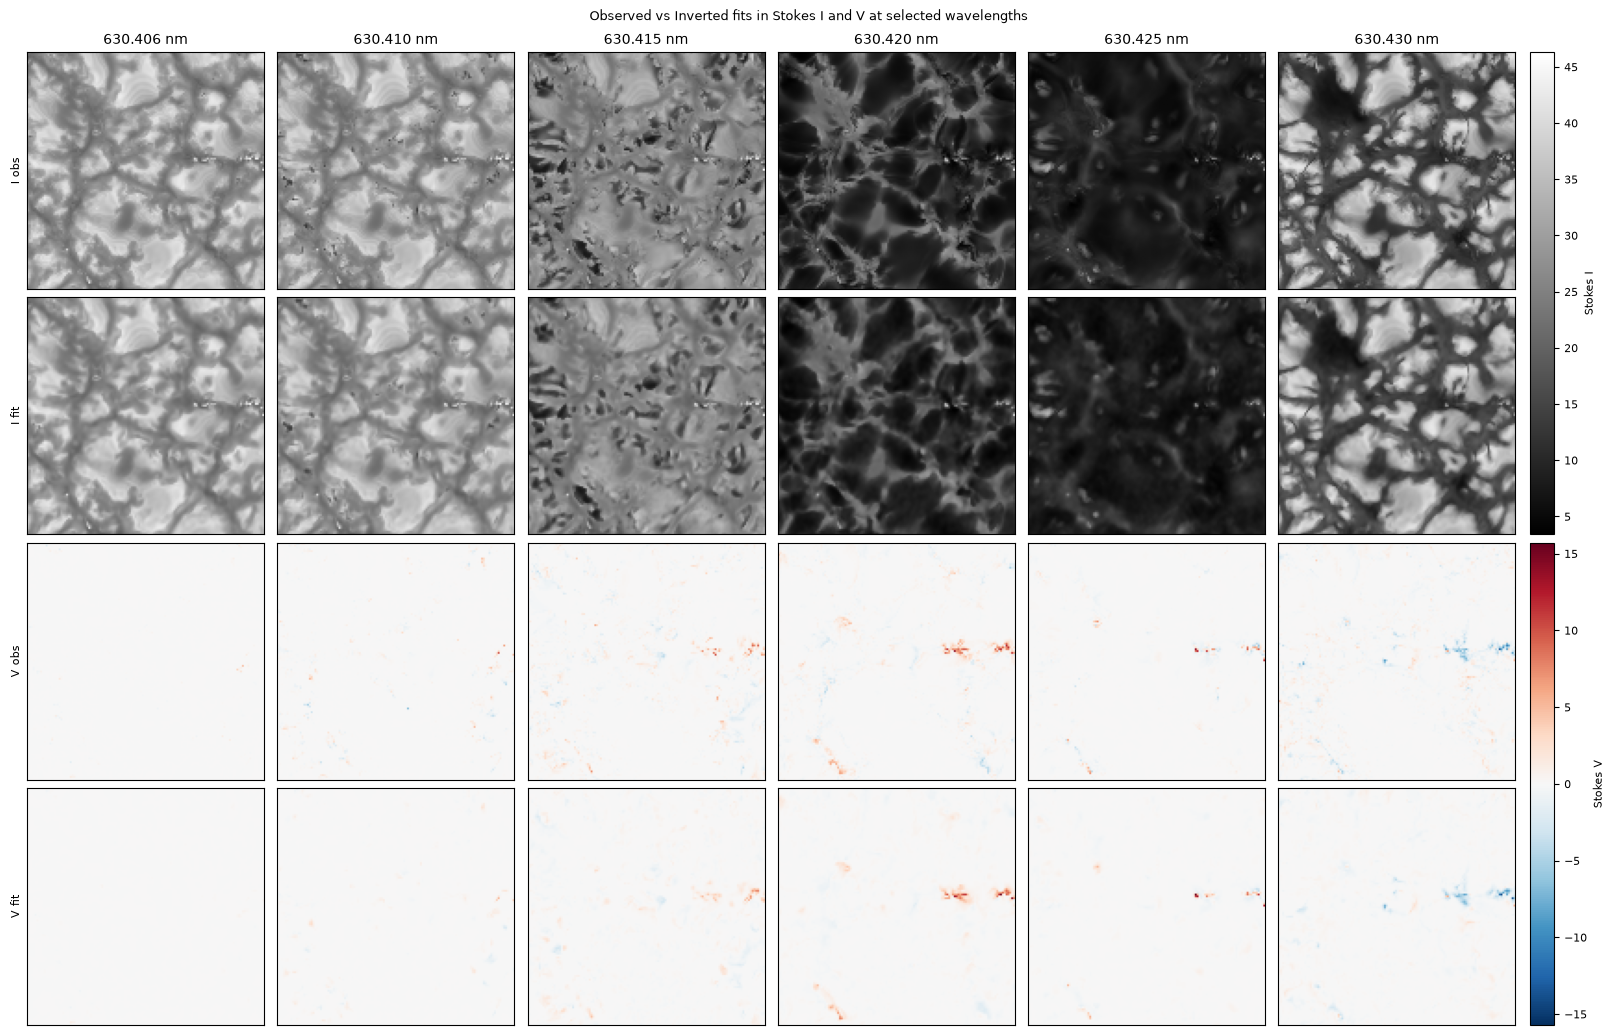

In [34]:
# 4x6 panel: rows = [I_obs, I_fit, V_obs, V_fit], cols = selected wavelengths in `idxs`
sel = np.array(idxs, dtype=int)[:6]

I_obs = obs[:, :, 0, sel]
V_obs = obs[:, :, 3, sel]
I_fit = I1[:, :, 0, sel]
V_fit = I1[:, :, 3, sel]

# consistent scales
vmin_I = min(I_obs.min(), I_fit.min())
vmax_I = max(I_obs.max(), I_fit.max())
vmax_V = max(np.abs(V_obs).max(), np.abs(V_fit).max())

fig, ax = plt.subplots(4, 6, figsize=(16, 10), layout='constrained')

for j, iw in enumerate(sel):
    ax[0, j].imshow(I_obs[:, :, j].T, origin='lower', cmap='gray', vmin=vmin_I, vmax=vmax_I)
    ax[1, j].imshow(I_fit[:, :, j].T, origin='lower', cmap='gray', vmin=vmin_I, vmax=vmax_I)
    ax[2, j].imshow(V_obs[:, :, j].T, origin='lower', cmap='RdBu_r', vmin=-vmax_V, vmax=vmax_V)
    ax[3, j].imshow(V_fit[:, :, j].T, origin='lower', cmap='RdBu_r', vmin=-vmax_V, vmax=vmax_V)

    ax[0, j].set_title(f"{waves[iw]:.3f} nm", fontsize=10)

for r in range(4):
    for c in range(6):
        ax[r, c].set_xticks([])
        ax[r, c].set_yticks([])

ax[0, 0].set_ylabel("I obs")
ax[1, 0].set_ylabel("I fit")
ax[2, 0].set_ylabel("V obs")
ax[3, 0].set_ylabel("V fit")

# colorbars (one for I, one for V)
imI = ax[0, 0].images[0]
imV = ax[2, 0].images[0]
fig.colorbar(imI, ax=ax[0:2, :], fraction=0.02, pad=0.01, label='Stokes I')
fig.colorbar(imV, ax=ax[2:4, :], fraction=0.02, pad=0.01, label='Stokes V')

plt.suptitle("Observed vs Inverted fits in Stokes I and V at selected wavelengths", y=1.02)
plt.show()

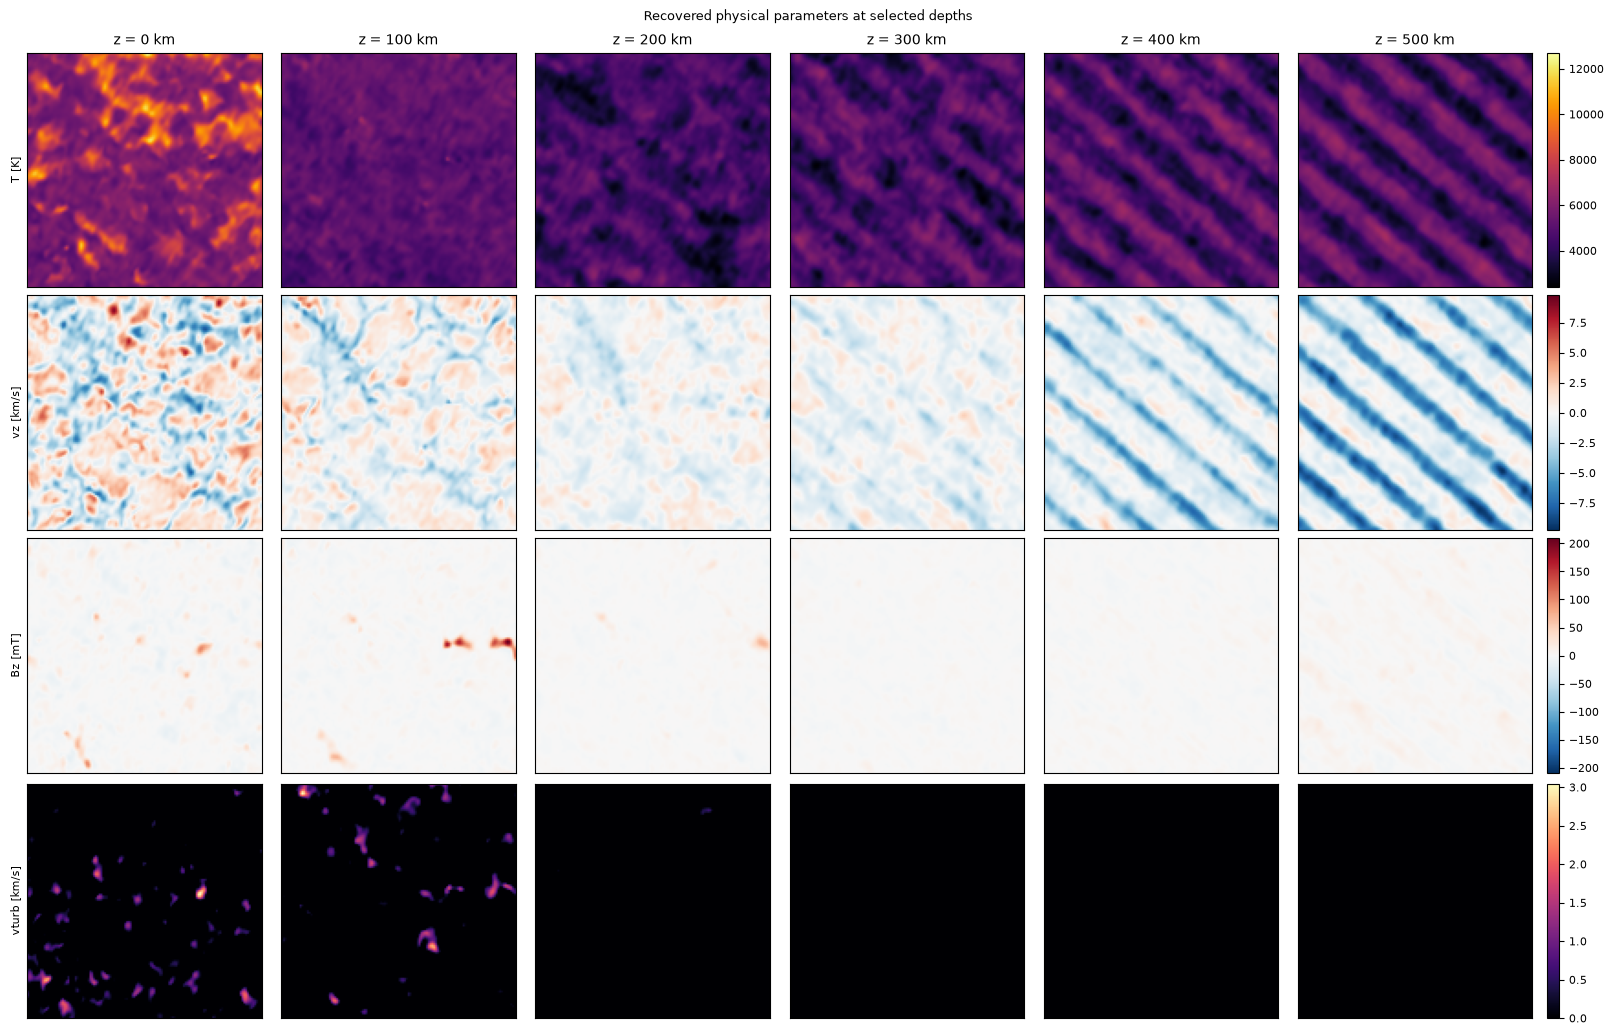

In [36]:
# 4x6 panel: rows = physical parameters, cols = selected depths in `izs`

sel_iz = np.array([5,10,15,20,25,30])

params4 = [
    ('T', 'T [K]', 1.0, 'inferno', False),
    ('vz', 'vz [km/s]', 1e-3, 'RdBu_r', True),
    ('Bz', 'Bz [mT]', 1e3, 'RdBu_r', True),
    ('vturb', 'vturb [km/s]', 1e-3, 'magma', False),
]

fig, ax = plt.subplots(4, 6, figsize=(16, 10), layout='constrained')

for r, (key, label, scale, cmap, sym) in enumerate(params4):
    cube = pred[key].reshape(nx, ny, nz) * scale
    stack_r = cube[:, :, sel_iz]

    if sym:
        vmax_r = np.max(np.abs(stack_r))
        vmin_r = -vmax_r
    else:
        vmin_r = np.min(stack_r)
        vmax_r = np.max(stack_r)

    for c, iz in enumerate(sel_iz):
        imr = ax[r, c].imshow(
            cube[:, :, iz].T, origin='lower', cmap=cmap, vmin=vmin_r, vmax=vmax_r
        )
        if r == 0:
            ax[r, c].set_title(f"z = {z_km[iz]:.0f} km", fontsize=10)
        ax[r, c].set_xticks([])
        ax[r, c].set_yticks([])

    ax[r, 0].set_ylabel(label)
    fig.colorbar(imr, ax=ax[r, :], fraction=0.02, pad=0.01)

plt.suptitle("Recovered physical parameters at selected depths", y=1.02)
plt.show()

In [37]:
af.save_params('/dat/milic/adora_pinn_develop/inverted_field.npz', ckpt['params'])
print('saved inverted field -> /dat/milic/adora_pinn_develop/inverted_field.npz  (', ckpt['step'], 'steps )')

saved inverted field -> /dat/milic/adora_pinn_develop/inverted_field.npz  ( 20000 steps )


### Summary
End-to-end PINN inversion of the observed batch: from the FAL-C warm start, the fit chi^2 drops and the
recovered spectra (I,Q,U,V), the longitudinal field Bz and the velocity vz are produced. Training is
continuable (re-run the continue cell) with an exponential-decay LR schedule; per-Stokes weights
(`sigma_stokes`) and the loss weights are hand-set knobs to tune the balance.